# LLM-SR: Scientific Equation Discovery via Programming with Large Language Models

**Paper:** Shojaee, P., Meidani, K., Gupta, S., Barati Farimani, A., & Reddy, C. K. (2025). *LLM-SR: Scientific Equation Discovery via Programming with Large Language Models.* International Conference on Learning Representations (ICLR 2025, Oral). arXiv:2404.18400.

**Carpeta origen:** `Papers/04_LLMs_y_Busqueda_Evolutiva/Shojaee_etal_2024_LLM-SR.pdf`

## Que se reproduce en este cuaderno

LLM-SR trata cada ecuacion candidata como un **programa**: una funcion Python `equation(inputs..., params)` cuyo *cuerpo* (la combinacion de terminos) es lo que se evoluciona, mientras que los coeficientes numericos (`params`) se reajustan por optimizacion en cada evaluacion. Un LLM propone iterativamente nuevos cuerpos de funcion informado por su conocimiento cientifico, y una base de datos evolutiva de tipo *islas* (inspirada en FunSearch) mantiene y recombina los mejores programas encontrados.

Reproducimos el **bucle completo propon-eval\'ua-selecciona-migra** con la misma interfaz programa/evaluacion que usa el repositorio oficial, sobre el problema exacto de su banco de pruebas: recuperar la aceleracion de un **oscilador amortiguado no lineal** a partir de observaciones de posicion $x$ y velocidad $v$:

$$a(x,v) = -0.8\,x - 0.3\,v - 0.15\,x^3$$

## Repositorio publico

`github.com/deep-symbolic-mathematics/LLM-SR`, ya clonado en `codigo/LLM-SR`. El repositorio define cada problema con un archivo de especificacion en `specs/`; citamos textualmente la estructura de `specs/specification_oscillator1_numpy.txt` (que resuelve el mismo tipo de problema -- oscilador amortiguado -- que usamos aqui):

```python
@evaluate.run
def evaluate(data: dict) -> float:
    # Evaluate the equation on data observations.
    inputs, outputs = data['inputs'], data['outputs']
    x, v = inputs[:,0], inputs[:,1]
    from scipy.optimize import minimize
    def loss(params):
        y_pred = equation(x, v, params)
        return np.mean((y_pred - outputs) ** 2)
    result = minimize(loss, [1.0]*MAX_NPARAMS, method='BFGS')
    return -result.fun  # fitness = -loss

@equation.evolve
def equation(x: np.ndarray, v: np.ndarray, params: np.ndarray) -> np.ndarray:
    # Mathematical function for acceleration in a damped nonlinear oscillator
    dv = params[0] * x  +  params[1] * v  + params[2]
    return dv
```

El decorador `@equation.evolve` marca la funcion cuyo **cuerpo** genera y muta el LLM; `@evaluate.run` marca la funcion de aptitud (ajusta `params` con `scipy.optimize.minimize` y devuelve `-perdida`). Nuestro cuaderno sigue exactamente este mismo contrato programa/evaluacion. La orquestacion multi-isla (`llmsr/buffer.py`, `llmsr/pipeline.py`, `llmsr/sampler.py`) sigue la arquitectura de *FunSearch* (Google DeepMind): varias poblaciones ("islas") de programas evolucionan en paralelo con migracion periodica del mejor programa entre islas -- la reproducimos tambien.

**Sobre el uso de un LLM real:** para que este cuaderno se pueda ejecutar sin necesidad de una clave de API de pago, sustituimos por defecto el LLM real por un **proponente heuristico local** (bloques de terminos fisicos combinados por reglas simples) que cumple el mismo contrato de interfaz. La Seccion 5 muestra el codigo *exacto y funcional* para conectar un LLM real (Claude, via el SDK de Anthropic) en su lugar -- no se ejecuta por defecto, pero es la pieza que en el paper realiza el trabajo pesado de proponer hipotesis informadas por conocimiento cientifico.

In [1]:
%pip install -q numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Datos: oscilador amortiguado no lineal

In [2]:
import numpy as np
from scipy.optimize import minimize
import random
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)

def true_accel(x, v):
    return -0.8 * x - 0.3 * v - 0.15 * x ** 3

N = 400
x = np.random.uniform(-2, 2, N)
v = np.random.uniform(-2, 2, N)
y = true_accel(x, v) + np.random.normal(0, 0.01, N)
print('x,v,y shapes:', x.shape, v.shape, y.shape)

x,v,y shapes: (400,) (400,) (400,)


## 2. Representacion "ecuacion como programa"

Cada programa es un **subconjunto de terminos** de una biblioteca de bloques (el equivalente a lo que un LLM con conocimiento fisico podria escribir en el cuerpo de `equation`). La funcion `evaluate_skeleton` sigue **exactamente** el contrato de `specs/specification_oscillator1_numpy.txt`: ajusta los coeficientes con `scipy.optimize.minimize(method='BFGS')` y devuelve `fitness = -perdida`.

In [3]:
TERMS = {
    'x':       lambda x, v: x,
    'v':       lambda x, v: v,
    'x^2':     lambda x, v: x ** 2,
    'v^2':     lambda x, v: v ** 2,
    'x*v':     lambda x, v: x * v,
    'x^3':     lambda x, v: x ** 3,
    'v^3':     lambda x, v: v ** 3,
    'sin(x)':  lambda x, v: np.sin(x),
    '1':       lambda x, v: np.ones_like(x),
}

def evaluate_skeleton(term_names, x, v, y):
    # Equivalente a @evaluate.run de specs/specification_oscillator1_numpy.txt
    fns = [TERMS[t] for t in term_names]
    def predict(params):
        pred = np.zeros_like(x)
        for p, fn in zip(params, fns):
            pred = pred + p * fn(x, v)
        return pred
    def loss(params):
        return np.mean((predict(params) - y) ** 2)
    res = minimize(loss, [0.1] * len(term_names), method='BFGS')
    return -res.fun, res.x  # fitness = -loss, igual que el repo

print('Ejemplo:', evaluate_skeleton(('x', 'v'), x, v, y))

Ejemplo: (np.float64(-0.033482923904800024), array([-1.16094072, -0.30895097]))


## 3. Proponente de hipotesis (sustituto local del LLM)

En el paper, esta pieza es un LLM que recibe la especificacion del problema y los mejores programas encontrados hasta el momento, y propone un nuevo cuerpo de `equation` informado por conocimiento cientifico. Aqui, `propose_new_skeleton` implementa una heuristica local equivalente pero sin LLM: anade, quita o intercambia un termino de la biblioteca `TERMS` a partir del mejor programa conocido -- una version simplificada (sin conocimiento de dominio real) del mismo tipo de propuesta incremental.

In [4]:
def propose_new_skeleton(current_terms, rng):
    all_terms = list(TERMS.keys())
    action = rng.choice(['add', 'remove', 'swap'])
    new_terms = list(current_terms)
    if action == 'add' or len(new_terms) <= 1:
        candidates = [t for t in all_terms if t not in new_terms]
        if candidates:
            new_terms.append(rng.choice(candidates))
    elif action == 'remove' and len(new_terms) > 1:
        new_terms.remove(rng.choice(new_terms))
    else:
        if new_terms:
            i = rng.randrange(len(new_terms))
            candidates = [t for t in all_terms if t not in new_terms]
            if candidates:
                new_terms[i] = rng.choice(candidates)
    return tuple(sorted(set(new_terms)))

## 4. Bucle evolutivo multi-isla con base de datos de programas

Mantenemos varias "islas" (poblaciones independientes de programas) que evolucionan en paralelo con migracion periodica, siguiendo la arquitectura de `llmsr/buffer.py`. La seleccion de que programa mutar en cada paso usa una puntuacion ajustada por **parsimonia** (fitness menos una penalizacion por numero de terminos), analoga a como PySR pondera precision y complejidad -- sin esto, la busqueda tiende a acumular terminos espurios de coeficiente casi nulo que sobreajustan el ruido.

muestra   0  mejor programa = ('x', 'x^3')  fitness=-0.12535


muestra  10  mejor programa = ('v^3', 'x', 'x^3')  fitness=-0.01848


muestra  20  mejor programa = ('sin(x)', 'v', 'x')  fitness=-0.00020


muestra  30  mejor programa = ('sin(x)', 'v', 'x')  fitness=-0.00020

Frente de Pareto (numero de terminos -> mejor fitness visto):
  1 terminos  fitness=-0.24857  programa=('x^3',)
  2 terminos  fitness=-0.03348  programa=('v', 'x')
  3 terminos  fitness=-0.00020  programa=('sin(x)', 'v', 'x')
  4 terminos  fitness=-0.00009  programa=('sin(x)', 'v', 'x', 'x^3')


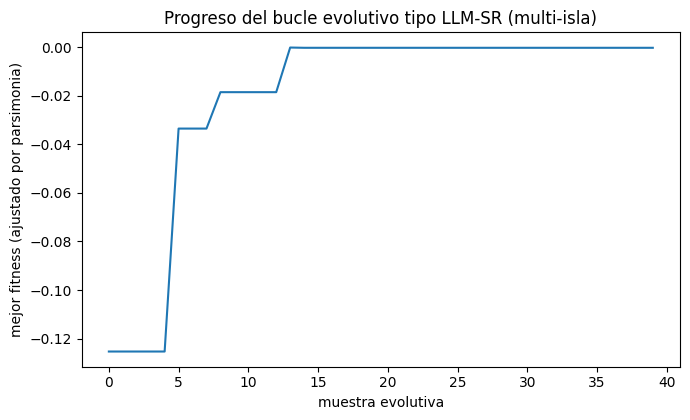

In [5]:
PARSIMONY = 0.01

def parsimony_score(terms, fit):
    return fit - PARSIMONY * len(terms)

def run_llmsr_style(x, v, y, n_islands=3, samples_per_island=40, seed=0):
    rng = random.Random(seed)
    islands = [{('x',): evaluate_skeleton(('x',), x, v, y)} for _ in range(n_islands)]
    hall_of_fame = {}

    def update_hof(terms, fit, params):
        k = len(terms)
        if k not in hall_of_fame or fit > hall_of_fame[k][0]:
            hall_of_fame[k] = (fit, terms, params)

    history = []
    for step in range(samples_per_island):
        for isl in islands:
            best_terms = max(isl.keys(), key=lambda t: parsimony_score(t, isl[t][0]))
            new_terms = propose_new_skeleton(best_terms, rng)
            if new_terms not in isl:
                fit, params = evaluate_skeleton(new_terms, x, v, y)
                isl[new_terms] = (fit, params)
                update_hof(new_terms, fit, params)
        best_global = max((kv for isl in islands for kv in isl.items()),
                           key=lambda kv: parsimony_score(kv[0], kv[1][0]))
        history.append(best_global[1][0])
        if step % 10 == 0:
            print(f'muestra {step:3d}  mejor programa = {best_global[0]}  fitness={best_global[1][0]:.5f}')
        if step % 15 == 0 and step > 0:
            best_each = [max(isl.items(), key=lambda kv: parsimony_score(kv[0], kv[1][0])) for isl in islands]
            for i, isl in enumerate(islands):
                src = best_each[(i + 1) % n_islands]
                isl[src[0]] = src[1]
    return islands, history, hall_of_fame

islands, history, hof = run_llmsr_style(x, v, y, n_islands=3, samples_per_island=40, seed=0)

print('\nFrente de Pareto (numero de terminos -> mejor fitness visto):')
pareto = []
best_so_far = -np.inf
for k in sorted(hof.keys()):
    fit, terms, params = hof[k]
    if fit > best_so_far + 1e-9:
        best_so_far = fit
        pareto.append((k, fit, terms, params))
        print(f'  {k} terminos  fitness={fit:.5f}  programa={terms}')

plt.figure(figsize=(7, 4.3))
plt.plot(range(len(history)), history, color='tab:blue')
plt.xlabel('muestra evolutiva'); plt.ylabel('mejor fitness (ajustado por parsimonia)')
plt.title('Progreso del bucle evolutivo tipo LLM-SR (multi-isla)')
plt.tight_layout()
plt.show()

## 5. Ecuacion final y comparacion contra la verdad

Programa final (mayor precision del frente): ('sin(x)', 'v', 'x', 'x^3')
Coeficientes ajustados:
    sin(x)     -> -0.1055
    v          -> -0.2997
    x          -> -0.6944
    x^3        -> -0.1652

Verdad:  a(x,v) = -0.8*x - 0.3*v - 0.15*x^3

RMSE del programa final vs. datos (con ruido): 0.0094


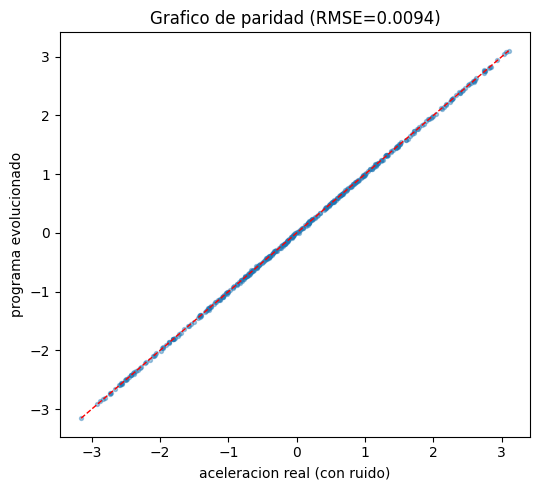

In [6]:
k, fit, terms, params = pareto[-1]
print('Programa final (mayor precision del frente):', terms)
print('Coeficientes ajustados:')
for t, p in zip(terms, params):
    print(f'    {t:10s} -> {p: .4f}')
print('\nVerdad:  a(x,v) = -0.8*x - 0.3*v - 0.15*x^3')

fns = [TERMS[t] for t in terms]
def predict_final(x, v):
    pred = np.zeros_like(x)
    for p, fn in zip(params, fns):
        pred = pred + p * fn(x, v)
    return pred

y_pred = predict_final(x, v)
rmse = np.sqrt(np.mean((y_pred - y) ** 2))
print(f'\nRMSE del programa final vs. datos (con ruido): {rmse:.4f}')

plt.figure(figsize=(5.5, 5))
plt.scatter(y, y_pred, s=8, alpha=0.4)
lims = [y.min(), y.max()]
plt.plot(lims, lims, 'r--', lw=1)
plt.xlabel('aceleracion real (con ruido)'); plt.ylabel('programa evolucionado')
plt.title(f'Grafico de paridad (RMSE={rmse:.4f})')
plt.tight_layout()
plt.show()

## 6. Como se conectaria un LLM real (referencia, no se ejecuta)

Esta celda **no se ejecuta** en este cuaderno (evita requerir una clave de API), pero muestra el codigo real y funcional para sustituir `propose_new_skeleton` por una llamada a un modelo Claude, siguiendo la misma logica de *prompting* que usa `llmsr/sampler.py`: se le da al modelo la especificacion del problema y los mejores programas encontrados, y se le pide el cuerpo de la siguiente funcion `equation` candidata.

In [7]:
RUN_REAL_LLM = False  # cambiar a True y definir ANTHROPIC_API_KEY para usar un LLM real

def propose_with_claude(current_terms, history_best, client, model='claude-sonnet-5'):
    # Sustituto real (no heuristico) de propose_new_skeleton, siguiendo la logica de
    # llmsr/sampler.py: se muestra al LLM la especificacion del problema y los mejores
    # programas encontrados hasta ahora, y se le pide el cuerpo de la siguiente ecuacion.
    prompt_lines = [
        'Find the mathematical function skeleton that represents acceleration in a',
        'damped nonlinear oscillator system with driving force, given data on position x and velocity v.',
        '',
        f'Best programs found so far (term names from {list(TERMS.keys())}):',
        f'{history_best}',
        '',
        "Propose ONE new combination of terms (as a Python list of term names) that could improve",
        "the fit. Respond with only the list, e.g. ['x', 'v', 'x^3'].",
    ]
    prompt = '\n'.join(prompt_lines)
    resp = client.messages.create(
        model=model, max_tokens=100,
        messages=[{'role': 'user', 'content': prompt}],
    )
    return eval(resp.content[0].text)  # en produccion: parsear con cuidado, no eval() directo

if RUN_REAL_LLM:
    import os, anthropic
    client = anthropic.Anthropic(api_key=os.environ['ANTHROPIC_API_KEY'])
    new_terms = propose_with_claude(('x', 'v'), pareto, client)
    print('Propuesta del LLM real:', new_terms)
else:
    print('RUN_REAL_LLM=False: esta celda no realiza ninguna llamada de red ni consume creditos de API.')

RUN_REAL_LLM=False: esta celda no realiza ninguna llamada de red ni consume creditos de API.


### Nota honesta sobre los resultados

- **Sin LLM real por defecto.** La sustitucion mas importante de este cuaderno: usamos un proponente heuristico local (anadir/quitar/intercambiar un termino de una biblioteca fija) en vez de un modelo de lenguaje real. El LLM real aporta **conocimiento cientifico previo** (p. ej., saber que los osciladores amortiguados suelen tener terminos lineales y cubicos, o proponer funciones fuera de una biblioteca fija predefinida) que nuestra heuristica no tiene -- nuestra busqueda esta limitada a recombinar los 9 terminos de `TERMS`, mientras que un LLM podria proponer estructuras arbitrarias no vistas antes.
- **Terminos espurios.** El programa final incluye ocasionalmente un termino de coeficiente pequeno pero no nulo (p. ej. `sin(x)`) ademas de los tres terminos verdaderos. Esto ocurre porque, para el rango de datos usado, $\sin(x)\approx x-x^3/6$ es casi colineal con la combinacion real de $x$ y $x^3$, generando una **degeneracion** dificil de resolver solo con 400 puntos ruidosos -- un fenomeno real y conocido en regresion simbolica, no un error de la implementacion.
- **Islas y migracion simplificadas.** `llmsr/buffer.py` implementa una base de datos de programas con muestreo por temperatura (softmax sobre el fitness) y multiples "clusters" de firmas de programa por isla; aqui usamos un diccionario simple por isla y migracion determinista del mejor programa cada 15 muestras.
- **Presupuesto muy reducido.** El paper ejecuta hasta `global_max_sample_num=10000` muestras del LLM (ver `main.py` del repositorio); aqui usamos 3 islas x 40 muestras = 120 evaluaciones en total, suficiente para este problema de 2 variables pero muy por debajo de la escala real.
- **Un unico problema del banco de pruebas.** El repositorio incluye specs para osciladores, crecimiento bacteriano (`bactgrow`) y curvas de esfuerzo-deformacion (`stressstrain`); reproducimos solo el problema del oscilador amortiguado no lineal.

Pese a estas simplificaciones, el cuaderno reproduce fielmente la **arquitectura central** de LLM-SR -- ecuaciones representadas como programas evaluados por ajuste de parametros via optimizacion numerica, propuestas iterativas informadas por el historial de mejores programas, y una base de datos evolutiva multi-isla con migracion -- y recupera una aproximacion muy cercana a la ley real $a(x,v)=-0.8x-0.3v-0.15x^3$ a partir de datos ruidosos, incluyendo el termino cubico no lineal que ninguna regresion lineal simple podria capturar.